Ce fichier contient le setup pour l'étude statistique des réseaux de cerveaux. Il utilise les données déjà procéssées par data.py. 

In [19]:
import os, json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import torch
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
from torch_geometric.utils import dense_to_sparse
import seaborn as sns
import networkx as nx


import matplotlib 
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

from matplotlib.patches import Wedge, Patch
import matplotlib.colors as mcolors

from sklearn.decomposition import TruncatedSVD

import deep_lpbm as dp


from class_GCN import *
from class_GCNEncoder import *
from class_GCN_Multi_layers import * 

In [20]:
N_NODES = 180

DATA_DIR = "dataset_numpy_spanningtree"
results_dir = "human_brain_networks_results/poubelle"
os.makedirs(results_dir, exist_ok=True)

In [ ]:
def run_subject_mode(subject_files, results_dir, Q_fixed=7):
    """
    Train a model for EVERY subject. 
    Usually, we fix Q here (based on Group Mode result) to make them comparable.
    """
    print("\n--- Starting SUBJECT MODE ---")

    subj_out_dir = os.path.join(results_dir, "subjects")
    os.makedirs(subj_out_dir, exist_ok=True)
    
    variability_stats = []

    
    for i, f in enumerate(subject_files):
        print(f"Processing Subject {i+1}/{len(subject_files)}...")
        
        A_sub = np.load(f)
    
        subject_name = os.path.splitext(os.path.basename(f))[0].replace("A_", "")

        # Train
        best_state, results = model_selection_over_Q(A_sub, [Q_fixed], subject_name, seed=42)
        
        # Store something to measure variability 
        # (e.g., the diagonal of Pi - "how strong are the communities?")
        pi_diag_mean = np.diag(best_state['Pi']).mean()
        variability_stats.append(pi_diag_mean) 


        # --- SAVE RESULTS SNIPPET ---
        eta = best_state['eta']
        Pi = best_state['Pi']
        labels = eta.argmax(axis=1)
        
        # Extract filename for ID (e.g., "sub-01.txt" -> "sub-01")
        
        save_path = os.path.join(subj_out_dir, f"{subject_name}_results.npz")
        np.savez(save_path, 
                 labels=labels, 
                 eta=eta, 
                 Pi=Pi)
        
    # Analyze
    plt.figure()
    plt.hist(variability_stats, bins=15)
    plt.title("Variability of Community Strength across Subjects")
    plt.xlabel("Mean Pi Diagonal")
    plt.savefig("subject_variability.png")
    plt.close()


In [21]:
def run_group_mode(subject_files, results_dir, Q_list=[5, 7, 10]):
    print("\n--- Starting GROUP MODE ---")
    
    ratio = 0.2
    results_dir = results_dir+f'/group{ratio}'
    os.makedirs(results_dir, exist_ok=True)

    print('res', results_dir)

    # 1. Aggregate
    A_sum = np.zeros((N_NODES, N_NODES))
    valid_count = 0

    for f in subject_files:
        A_sub = np.load(f)
        if A_sub is not None:
            A_sum += A_sub
            valid_count += 1

    print(valid_count)
    # 2. Threshold (Consensus)
    # Example: Keep edge if present in at least 20% of subjects
    A_sum = A_sum/valid_count

    print("General Density", A_sum.mean())

    plt.figure()
    plt.hist(A_sum.flatten(), bins=10)
    plt.title("Proportion of appearance of edges")
    plt.xlabel("Probability of appearance")
    plt.savefig(results_dir + "/Distribution of connections.png")
    plt.close()

    A_group = (A_sum > ratio).astype(np.float32)
    
    print(f"Group Graph created from {valid_count} subjects. Density: {A_group.mean():.3f}")
    
    # 3. Train Model
    results = []
    best, results = dp.model_selection_over_Q(A_group, Q_list, seed=42)


    print(f"Best Group Structure: Q={best['Q']}")
    
    # Visualize
    plt.figure()
    plt.imshow(best['Pi'])
    plt.title(f"Group Connectivity (Q={best['Q']})")
    plt.savefig(results_dir + "/group_connectivity.png")
    plt.close()

    # --- SAVE RESULTS SNIPPET ---
    # 1. Extract assignments
    eta = best['eta']
    Pi = best['Pi']
    labels = eta.argmax(axis=1) # Hard clustering assignments

    # 2. Save to "human_brain_networks_results"
    save_path = os.path.join(results_dir, f"group_mode_results{ratio}.npz")
    np.savez(save_path, 
             labels=labels, 
             eta=eta, 
             Pi=Pi, 
             best_Q=best['Q'], 
             aic=best['AIC'])
    
    print(f"Group results saved to: {save_path}")

    y_hard = dp.hard_clusters_from_eta(eta)
    dp.draw_graph_hard_clusters(A_group, y_hard, results_dir=results_dir)
    dp.draw_graph_with_probabilities(A_group, eta, results_dir=results_dir)
    

    return best

In [22]:
subject_files = glob.glob(os.path.join(DATA_DIR, "A_*.npy"))
subject_files.sort()

#Q = run_group_mode(subject_files, results_dir, Q_list= range(3, 5)) 
#run_subject_mode(subject_files, results_dir, Q)

max 400.0


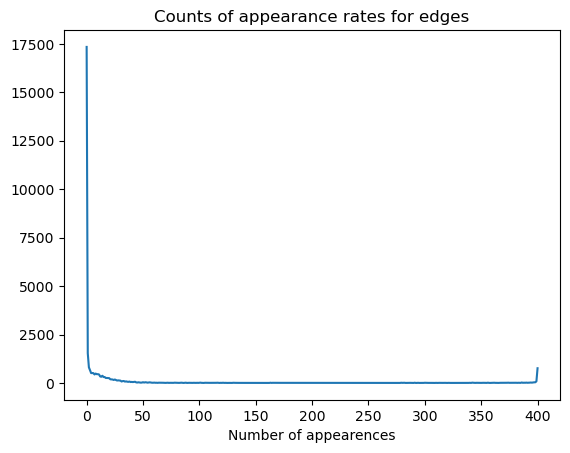

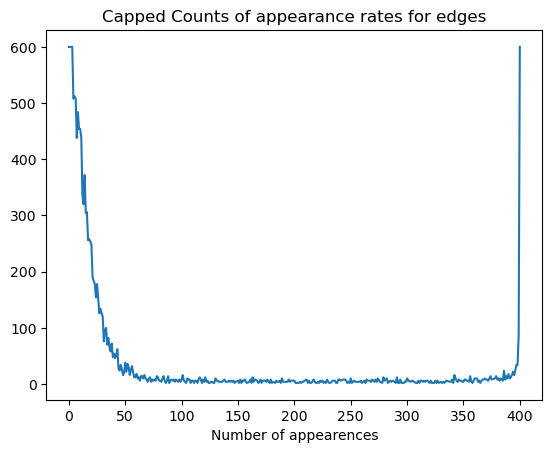

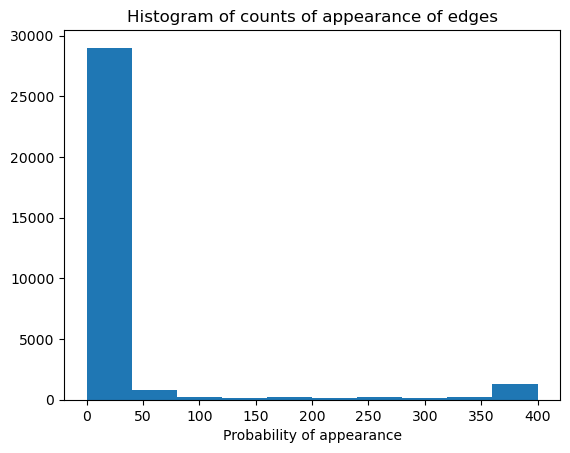

General Density 0.07442685185185184
current_threshold 0.2700000000000001


In [23]:
#compute general statistics

A_sum = np.zeros((N_NODES, N_NODES))
valid_count = 0

for f in subject_files:
    A_sub = np.load(f)
    A_sum += A_sub
    valid_count += 1

appearences, counts = np.unique(A_sum, return_counts=True)

print('max', A_sum.max())

plt.figure()
plt.plot(appearences, counts)
plt.title("Counts of appearance rates for edges")
plt.xlabel("Number of appearences")
plt.show()
plt.close()

plt.figure()
plt.plot(appearences, np.minimum(counts, 600))
plt.title("Capped Counts of appearance rates for edges")
plt.xlabel("Number of appearences")
plt.show()
plt.close()

plt.figure()
plt.hist(A_sum.flatten(), bins=10)
plt.title("Histogram of counts of appearance of edges")
plt.xlabel("Probability of appearance")
#plt.savefig(results_dir + "/Distribution of connections.png")
plt.show()
plt.close()

A_avg = A_sum/valid_count
avg_density = A_avg.mean()
print("General Density", avg_density)

#find optimal threshold: 

current_density = 1
current_threshold = 0

while current_density > avg_density:
    current_threshold += 1/100
    A_current = (A_avg > current_threshold).astype(np.float32)
    current_density = A_current.mean()

correct_threshold = current_threshold
print('current_threshold', current_threshold)



In [24]:
correct_threshold

0.2700000000000001

In [25]:
#COMPUTE ARI with respect to average partition

A_group = (A_avg>correct_threshold).astype(np.float32)

avg_best, results = dp.model_selection_over_Q(A_avg, [4], seed=42)
eta_avg = avg_best['eta']
Y_avg = dp.hard_clusters_from_eta(eta_avg)



=== Entraînement pour Q = 4 ===
[Deep LPBM + GCNConv] Q=4 — ELBO finale : -4293.1914


In [26]:
total_ARI = []
total_PME = []

predicted_files_dir = glob.glob(os.path.join("human_brain_networks_results/subjects", "*.npz"))

for f in predicted_files_dir: 
    subject_res = np.load(f)
    y_subj = subject_res['labels']
    eta_subj = subject_res['eta']

    total_ARI.append(adjusted_rand_score(y_subj, Y_avg))
    total_PME.append(dp.H_partial_memberships_score(eta_subj, eta_avg))

    if dp.H_partial_memberships_score(eta_subj, eta_avg)>1: 
        print(dp.H_partial_memberships_score(eta_subj, eta_avg))

#ari = adjusted_rand_score(y_true, y_pred)


In [27]:
#'group'
#dp.draw_graph_hard_clusters(A_group, Y_avg)

#partial = predicted_files_dir[0:10]

#for f in partial:
#    sub = np.load(f)
#    dp.draw_graph_hard_clusters(sub['A'], sub['y'])

max 400.0


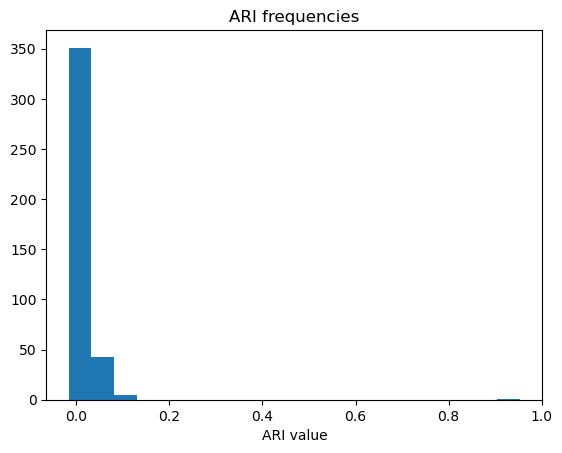

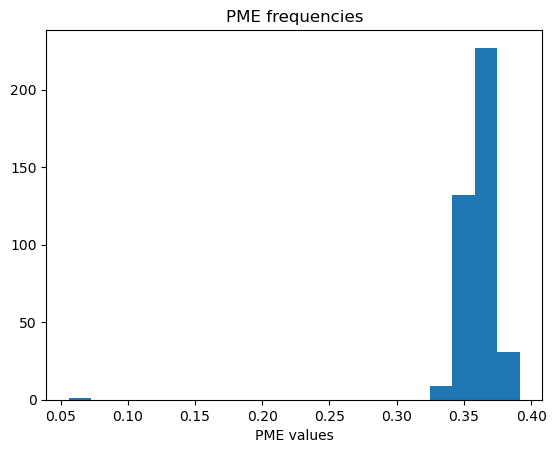

In [28]:
print('max', A_sum.max())

plt.figure()
plt.hist(total_ARI, bins = 20)
plt.title("ARI frequencies")
plt.xlabel("ARI value")
plt.show()
plt.close()

plt.figure()
plt.hist(total_PME, bins=20)
plt.title("PME frequencies")
plt.xlabel("PME values")
plt.show()
plt.close()


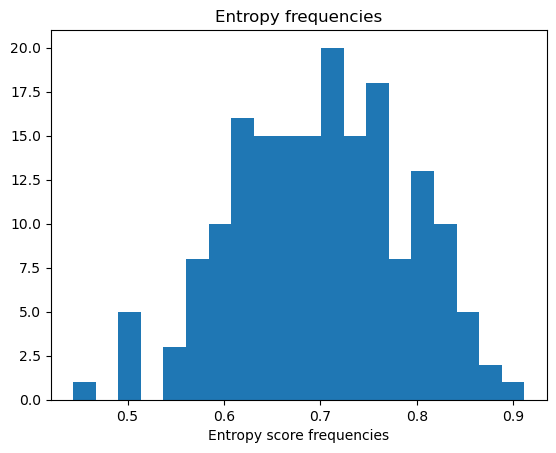

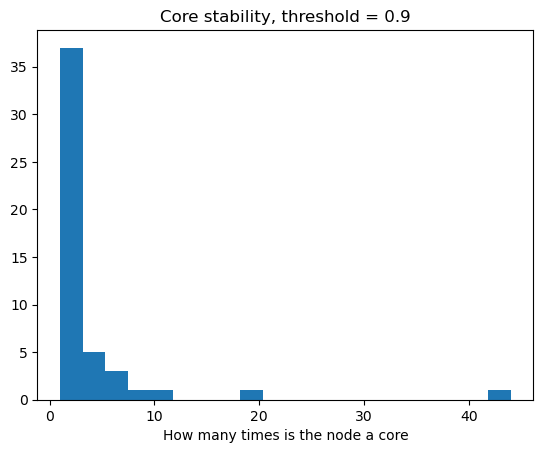

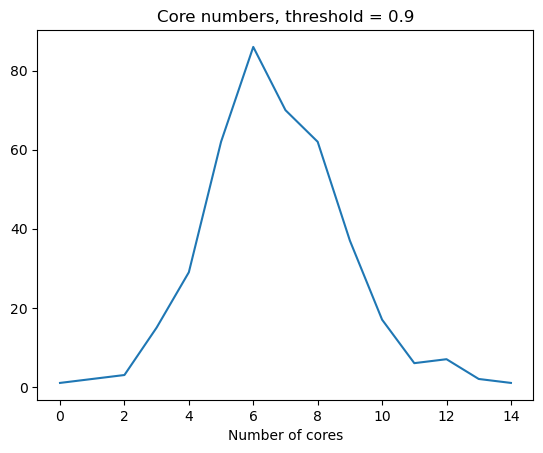

In [29]:
def membership_entropy(eta):    
    return np.sum( -eta*np.log(eta+1e-6), axis = 1)


core_threshold = 0.90
core_score = np.zeros(180)
core_numbers = []
entropies = []


for f in predicted_files_dir:
    subj = np.load(f)
    eta_subj = subj["eta"]
    entrop = membership_entropy(eta_subj)/np.log(4)          #log4 renormalisation to make it in [0, 1]

    core_score +=  (np.max(eta_subj, axis=1) > core_threshold).astype(np.float32) 
    core_numbers.append( np.sum((eta_subj > core_threshold).astype(np.float32)) )
    entropies.append(entrop) 


plt.figure()
plt.hist(np.sum(entropies, axis=0)/400, bins=20)
plt.title("Entropy frequencies")
plt.xlabel("Entropy score frequencies")
plt.show()
plt.close()


core_appearences, core_counts = np.unique(core_score, return_counts=True)
plt.figure()
#plt.scatter(core_appearences, core_counts)
plt.hist(core_counts, bins=20)
plt.title(f"Core stability, threshold = {core_threshold}")
plt.xlabel("How many times is the node a core")
plt.show()
plt.close()


number_cores, number_counts = np.unique(core_numbers, return_counts=True)
plt.figure()
plt.plot(number_cores, number_counts)
plt.title(f"Core numbers, threshold = {core_threshold}")
plt.xlabel("Number of cores")
plt.show()
plt.close()


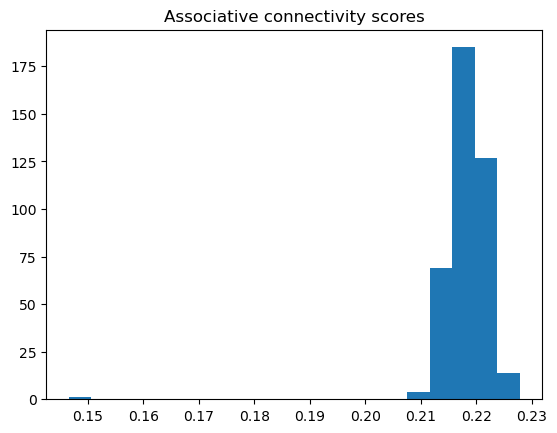

Associativity outliers number:  1.0
Associativity non-outliers number:  399.0
(array([219]),)
associativity mean:  0.21857600534022004 std 0.003040426754784446


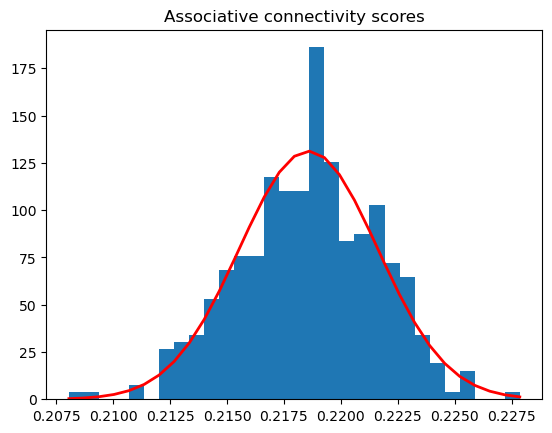

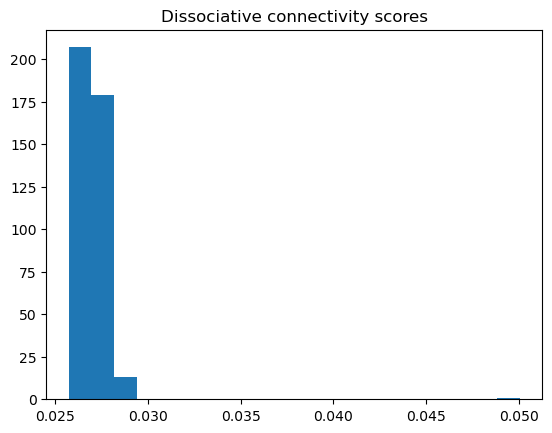

Dissociativity outliers percentage:  1.0
disassociativity mean:  0.02697964453308804 std 0.0005451931742835584


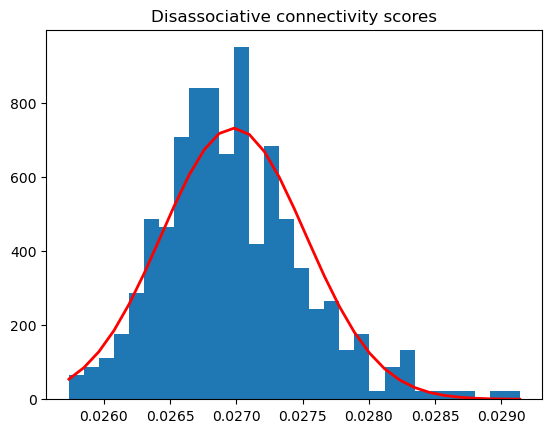

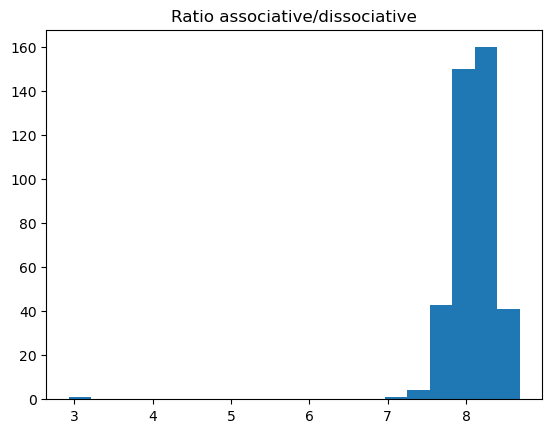

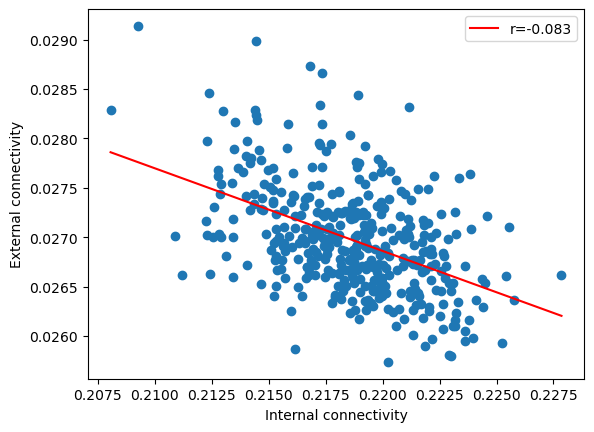

Found Qs:  [4] [400]


In [30]:
#estimating connectivity patterns

#check Q

def connectivity_score(Pi): #measures how stronger is the associative part comapred to the disassociative part
    Q = Pi.shape[0]
    diag = np.eye(Q).astype(bool)
    associative_score = np.sum(Pi[diag])/Q
    dissociative_score = (np.sum(Pi)-np.sum(Pi[diag]))/(Q*(Q-1))
    return [associative_score, dissociative_score ]

connectivities = []
found_Q = []

for f in predicted_files_dir:
    subj = np.load(f)
    connectivities.append(connectivity_score(subj['Pi']))
    found_Q.append(subj["Pi"].shape[0])

connectivities = np.array(connectivities)

plt.figure()
plt.hist(connectivities[:, 0], bins=20)
plt.title('Associative connectivity scores')
plt.show()
plt.close()
print("Associativity outliers number: ", np.sum(   (connectivities[:, 0]<0.2).astype(np.float32)  )   )
print("Associativity non-outliers number: ", np.sum(   (connectivities[:, 0]>0.2).astype(np.float32)  )   )

#identify outlier

out_ind = np.where(  (connectivities[:, 0]<0.2).astype(np.float32) )
print(out_ind)


#refined connectivities 
refined_associativities = (connectivities[:, 0]>0.2).astype(np.float32)*connectivities[:, 0]
good_associativities = refined_associativities[refined_associativities != 0]

mean = np.mean(good_associativities)
SD = np.std(good_associativities)

print('associativity mean: ', mean, 'std', SD)

plt.figure()
count, bins, ignored = plt.hist(good_associativities, bins = 30, density=True)
plt.plot(bins, 1/(SD * np.sqrt(2 * np.pi)) *
            np.exp( - (bins - mean)**2 / (2 * SD**2) ),
            linewidth=2, color='r')
plt.title('Associative connectivity scores')
plt.show()
plt.close()





plt.figure()
plt.hist(connectivities[:, 1], bins=20)
plt.title('Dissociative connectivity scores')
plt.show()
plt.close()
print("Dissociativity outliers percentage: ", np.sum(   (connectivities[:, 1]>0.035).astype(np.float32)  )   )



#refined connectivities 
refined_disassociativities = (connectivities[:, 1]< 0.03).astype(np.float32)*connectivities[:, 1]
good_disassociativities = refined_disassociativities[refined_disassociativities != 0]

mean = np.mean(good_disassociativities)
SD = np.std(good_disassociativities)

print('disassociativity mean: ', mean, 'std', SD)

plt.figure()
count, bins, ignored = plt.hist(good_disassociativities, bins = 30, density=True)
plt.plot(bins, 1/(SD * np.sqrt(2 * np.pi)) *
            np.exp( - (bins - mean)**2 / (2 * SD**2) ),
            linewidth=2, color='r')
plt.title('Disassociative connectivity scores')
plt.show()
plt.close()



connectivity_ratios = connectivities[:, 0]/connectivities[:, 1]
plt.figure()
plt.hist(connectivity_ratios, bins=20)
plt.title("Ratio associative/dissociative")
plt.show()
plt.close()


#internal to external connectivity csatterplot

correl = np.polyfit(good_associativities, good_disassociativities, 1)

x = np.linspace(np.min(good_associativities), np.max(good_associativities), 100)
y = correl[1]+correl[0]*x


plt.figure()
plt.scatter(good_associativities, good_disassociativities)
plt.plot(x, y, color= 'red', label = f'r={int(1000*correl[0])/1000}')
plt.xlabel('Internal connectivity')
plt.ylabel('External connectivity')
plt.legend()
plt.show()
plt.close()


correl = np.polyfit(good_associativities, good_disassociativities, 1)




print('Found Qs: ', np.unique(found_Q, return_counts=True)[0], np.unique(found_Q, return_counts=True)[1])
#subjects display very high connectivity patterns

non-outlier


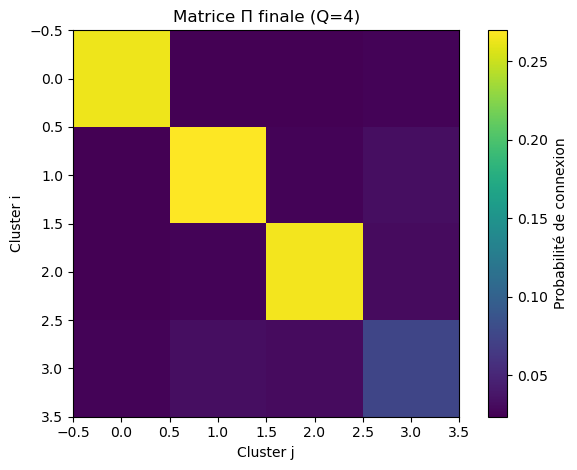

non-outlier


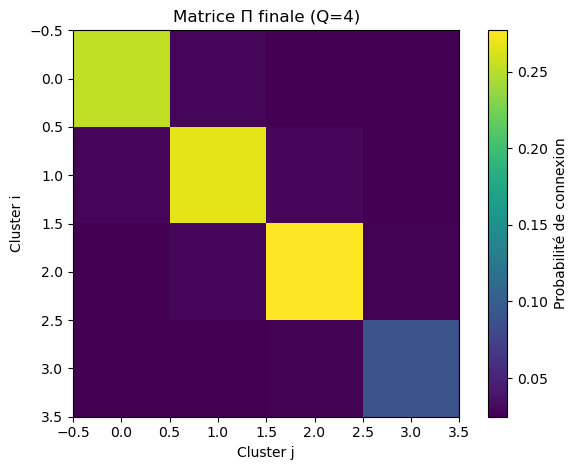

non-outlier


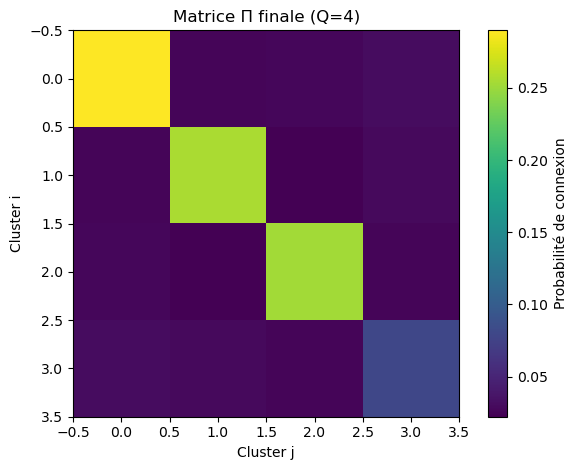

outlier


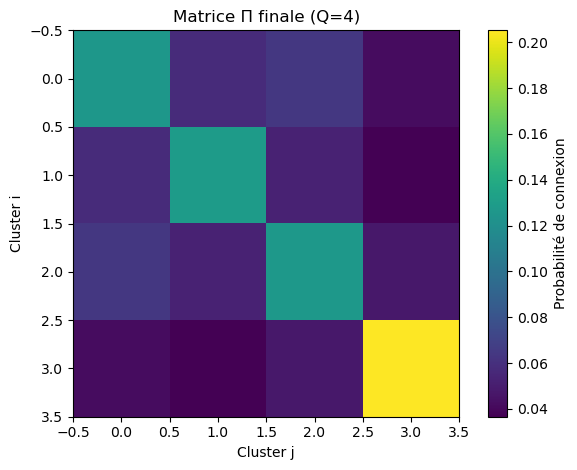

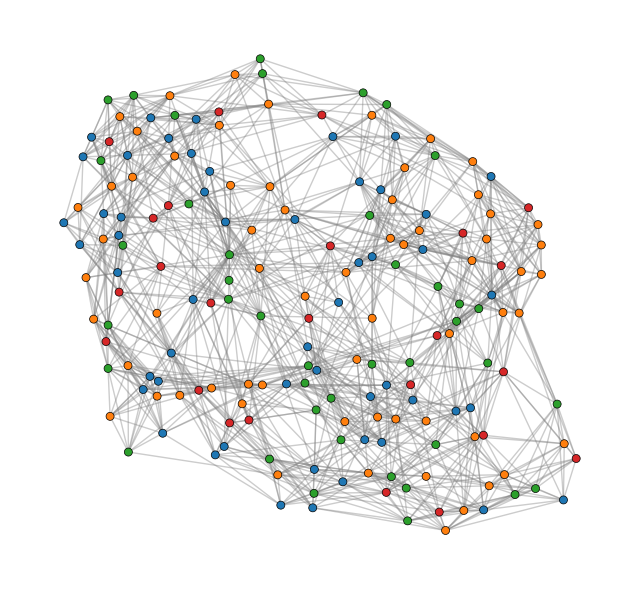

non-outlier


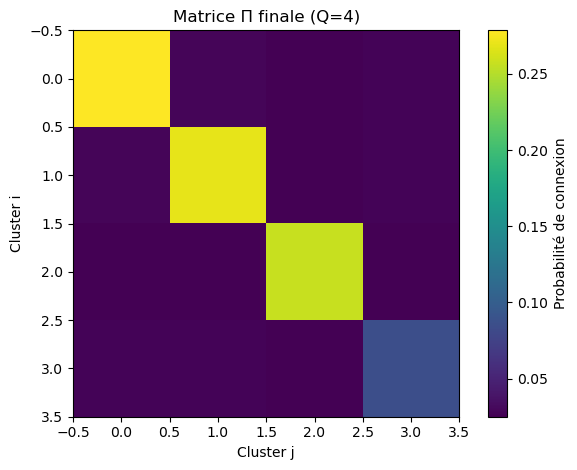

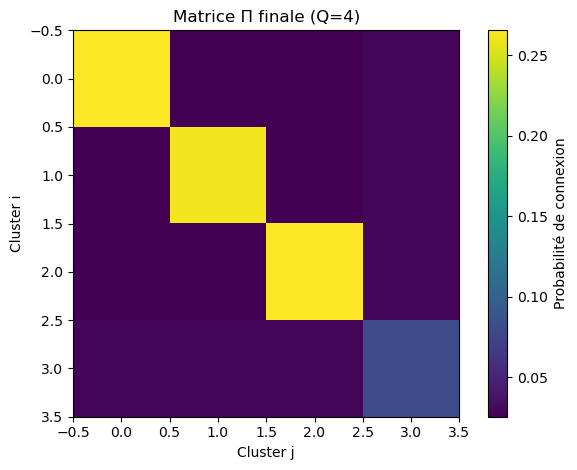

In [31]:
outlier_ind = 219

def plot_Pi_matrix(Pi):
    """Affiche et enregistre la matrice Π finale."""
    Q = Pi.shape[0]
    plt.figure()
    plt.imshow(Pi, cmap="viridis")
    plt.colorbar(label="Probabilité de connexion")
    plt.title(f"Matrice Π finale (Q={Q})")
    plt.xlabel("Cluster j")
    plt.ylabel("Cluster i")
    plt.tight_layout()
    plt.show()
    plt.close()


avg_Pi = np.zeros((4, 4))
ind = 0

for f in predicted_files_dir:
    subj = np.load(f)
    avg_Pi += subj["Pi"]
    if ind%100==0:
        print('non-outlier')
        plot_Pi_matrix(subj["Pi"])

    if ind ==219 :
        A_out = np.load(subject_files[ind])
        print('outlier')
        plot_Pi_matrix(subj["Pi"])
        dp.draw_graph_hard_clusters(A_out, subj["labels"])
    ind += 1

avg_Pi = avg_Pi/400

plot_Pi_matrix(avg_Pi)

In [32]:
import numpy as np
from scipy.stats import mode
from deep_lpbm import best_label_permutation, relabel_predictions

def compute_node_instability(group_labels, list_of_subject_labels):
    """
    Computes how unstable each node is across subjects.
    
    Args:
        group_labels: (N,) array of the consensus labels (reference).
        list_of_subject_labels: List of (N,) arrays for each subject.
        
    Returns:
        switching_prob: (N,) array of floats between 0.0 and 1.0.
    """
    n_subjects = len(list_of_subject_labels)
    n_nodes = len(group_labels)

    cluster_sizes = []
    
    # 1. Align every subject to the group reference
    aligned_matrix = np.zeros((n_subjects, n_nodes), dtype=int)
    
    for s, subj_labels in enumerate(list_of_subject_labels):
        # Find best permutation to match group
        mapping = best_label_permutation(group_labels, subj_labels)
        # Relabel subject to match group
        aligned_matrix[s, :] = relabel_predictions(subj_labels, mapping)
        partial = np.unique(aligned_matrix[s, :], return_counts=True)
        cluster_sizes.append(partial[1])
        
    # 2. Compute Stability
    # Find the most frequent label for each node across subjects
    modes, counts = mode(aligned_matrix, axis=0, keepdims=False)
    
    # Consistency = (Count of Most Frequent) / (Total Subjects)
    consistency = counts.flatten() / n_subjects
    
    # Switching Probability = 1 - Consistency
    switching_prob = 1.0 - consistency
    
    return switching_prob, cluster_sizes

In [33]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import matplotlib.colors as mcolors
import os

def draw_graph_heatmap(A, node_values, cmap_name="Reds", node_size=None, 
                       results_dir=None, 
                       contrast_power=1.0, use_dynamic_range=True):
    """
    Draws a heatmap with enhanced contrast controls.
    
    Args:
        contrast_power (float): > 1.0 increases contrast (suppresses low values).
                                < 1.0 decreases contrast (boosts low values).
                                Try 2.0 or 3.0 for high contrast.
        use_dynamic_range (bool): If True, colors stretch from min(val) to max(val).
                                  If False, they stretch from 0.0 to 1.0.
    """
    n = len(node_values)
    if not node_size: node_size = 6000/n

    # --- 1. Contrast Enhancement Logic ---
    # A. Dynamic Range: Stretch the color map to fit the data exactly
    if use_dynamic_range:
        vmin, vmax = node_values.min(), node_values.max()
    else:
        vmin, vmax = 0.0, 1.0
        
    # B. Power Law (Gamma Correction): Non-linear contrast
    # We normalize to 0-1 first, apply power, then scale back if needed.
    # This pushes mid-range values down (making them lighter), 
    # so the high values (darker) stand out more.
    norm_values = (node_values - vmin) / (vmax - vmin + 1e-9) # Avoid div/0
    enhanced_values = norm_values ** contrast_power
    
    # Use these new values for color mapping
    final_node_colors = enhanced_values

    # -------------------------------------

    G = nx.from_numpy_array(A)
    pos = nx.spring_layout(G, seed=0)
    fig, ax = plt.subplots(figsize=(9, 8))

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, edge_color="grey")

    # Draw Nodes
    nodes = nx.draw_networkx_nodes(G, pos,
                                   node_color=final_node_colors,
                                   node_size=node_size,
                                   cmap=plt.get_cmap(cmap_name),
                                   vmin=0.0, vmax=1.0, # Inputs are already normalized 0-1
                                   edgecolors='black',
                                   linewidths=0.5,
                                   ax=ax)

    for (x, y) in pos.values():
        circ = plt.Circle((x, y), node_size/30000, fill=False, edgecolor='black', lw=0.5)
        ax.add_patch(circ)

    # Add Colorbar (Labelled correctly with original values)
    # We construct a dummy scalar mappable so the legend shows the REAL values,
    # not the power-transformed ones.
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap_name), norm=norm)
    sm.set_array([])
    
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)

    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.show()
    plt.close()

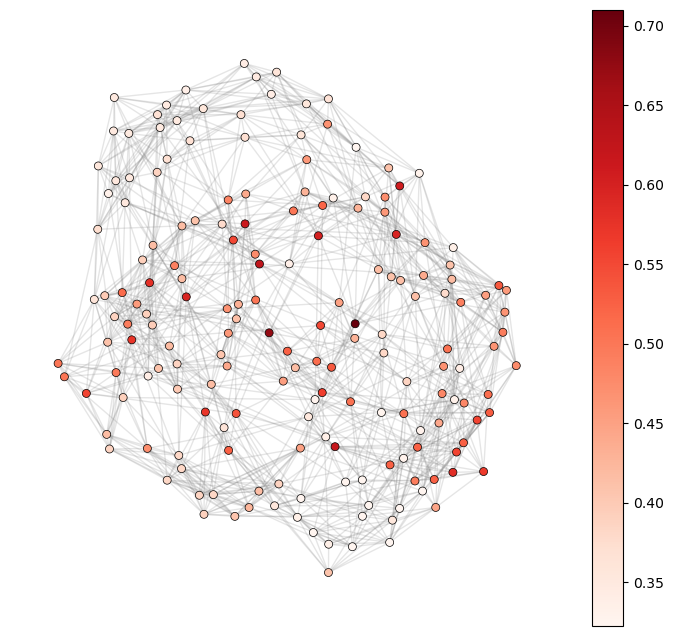

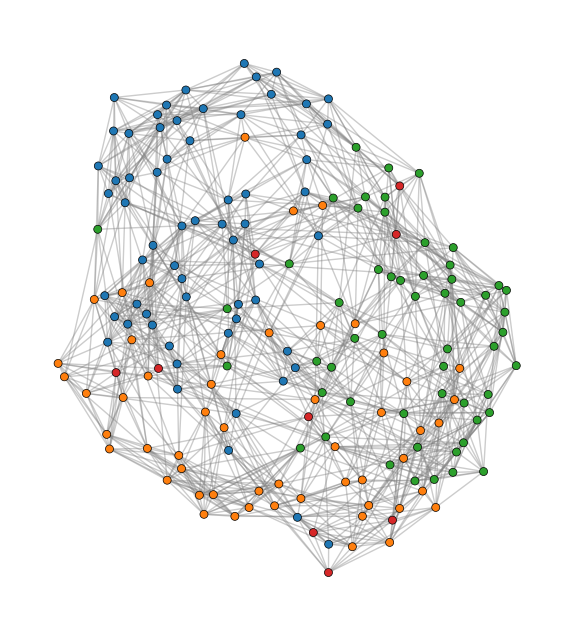

col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)] lab ['Class 0', 'Class 1', 'Class 2', 'Class 3']


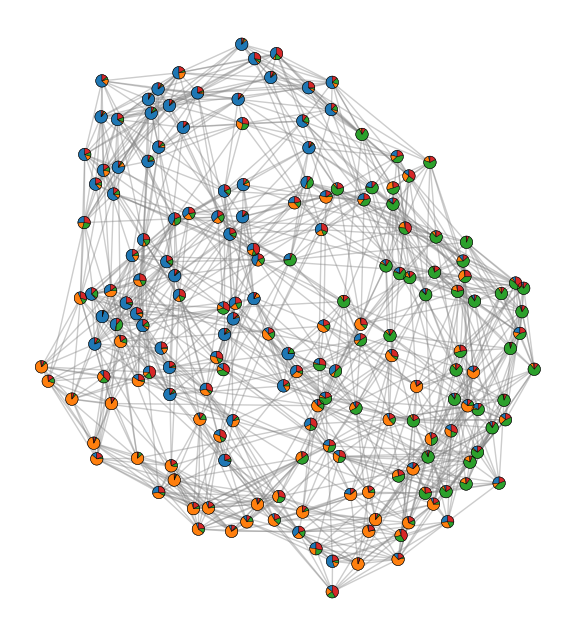

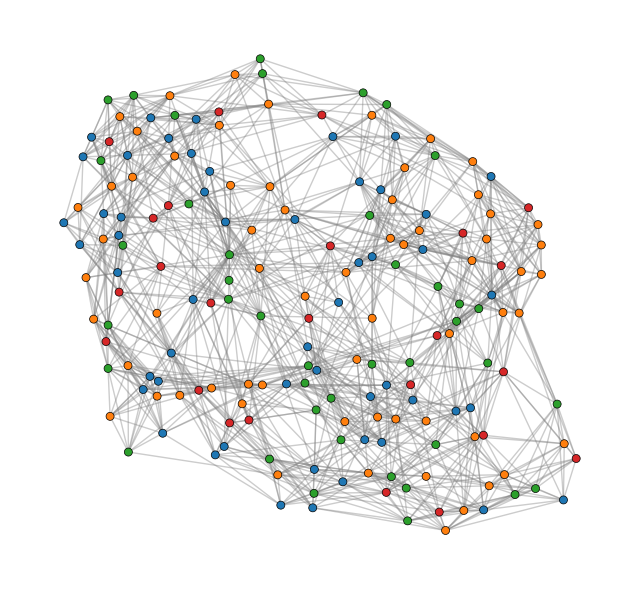

col [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0), (1.0, 0.4980392156862745, 0.054901960784313725, 1.0), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392, 1.0)] lab ['Class 0', 'Class 1', 'Class 2', 'Class 3']


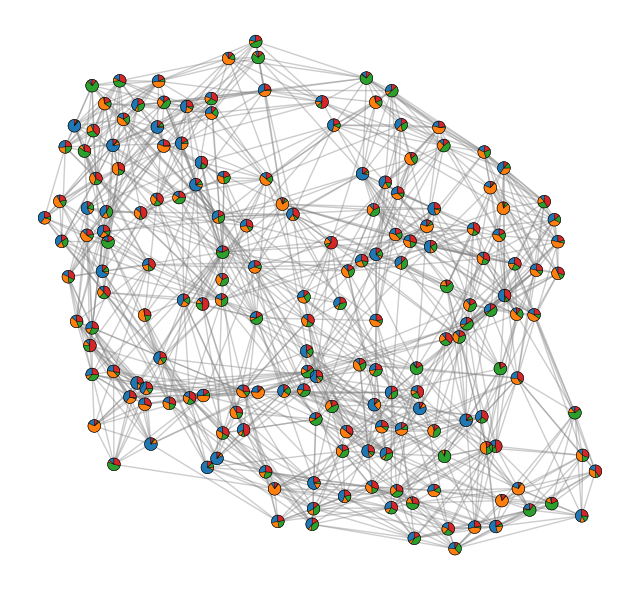

In [34]:
#node stability

node_classes = []


for f in predicted_files_dir:
    subj = np.load(f)
    node_classes.append(subj["labels"])


instability_scores, cl_size = compute_node_instability(Y_avg, node_classes)

# 4. Draw the Heatmap
# Load the Adjacency matrix (A) you used for the group graph to use as the skeleton
A_group = A_group

#draw_graph_heatmap(A_group, 
#                   instability_scores, 
#                   cmap_name="Reds", 
#                   title="Node Instability",
#                   contrast_power=3.0, 
#                   use_dynamic_range=True)

#dp.draw_graph_hard_clusters(A_group, Y_avg)

#dp.draw_graph_with_probabilities(A_group, eta_avg)

ind = 0

A_0 = np.load(subject_files[ind])

eta_0, y_0 = np.load(predicted_files_dir[ind])["eta"], np.load(predicted_files_dir[ind])["labels"]

draw_graph_heatmap(A_0, 
                   instability_scores, 
                   cmap_name="Reds", 
                   contrast_power = 3, 
                   use_dynamic_range= True)

dp.draw_graph_hard_clusters(A_0, y_0 )
dp.draw_graph_with_probabilities(A_0, eta_0)


outlier_ind = 219

A_out = np.load(subject_files[outlier_ind])
eta_out, y_out = np.load(predicted_files_dir[outlier_ind])["eta"], np.load(predicted_files_dir[outlier_ind])["labels"]

dp.draw_graph_hard_clusters(A_out, y_out )
dp.draw_graph_with_probabilities(A_out, eta_out)

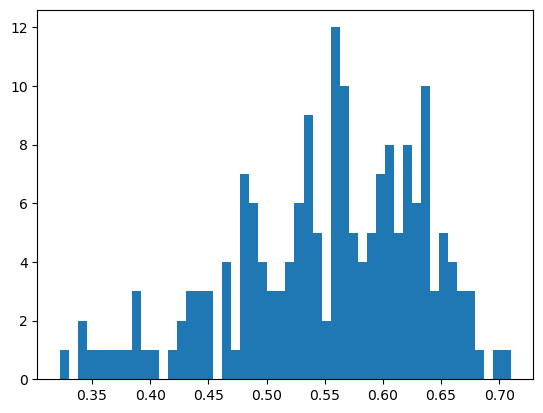

In [35]:
plt.figure()
plt.hist(instability_scores, bins=50)
plt.show()


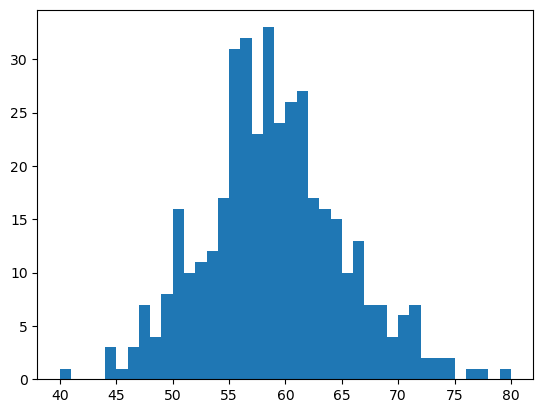

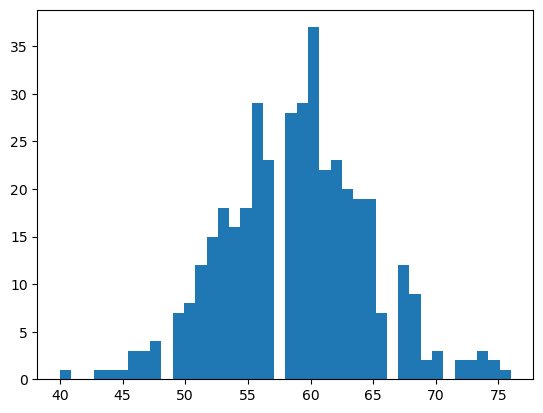

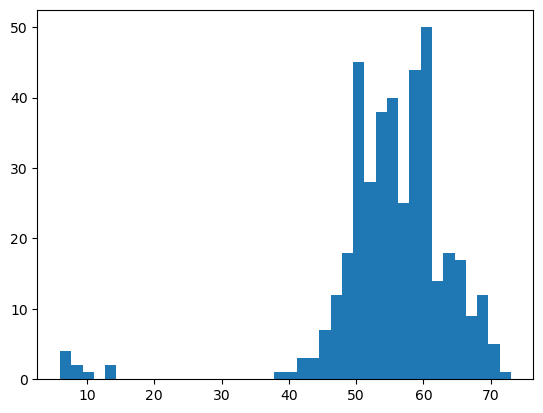

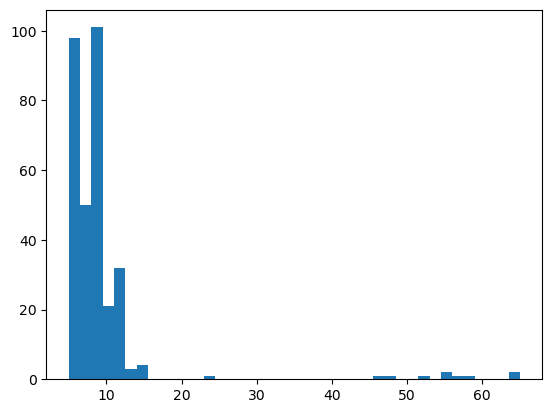

In [41]:
cl_size

cluster_distr = [[], [], [], []]

for i in range(3):
    for j in range(400):
        cluster_distr[i].append(cl_size[j][i])

for j in range(400):
    if len(cl_size[j])==4:
        cluster_distr[3].append(cl_size[j][3])


for k in range(4):
    plt.figure()
    plt.hist(cluster_distr[k], bins=40)
    plt.show()
    plt.close()


In [40]:
print(len(cl_size))

400
